## Function 2 — Week 8: SFGP with qLogNEI Acquisition

This notebook processes the **Week 8** updated data for Function 2 and proposes the next sample point for Week 9 using the same strategy as Week 7:

- **Surrogate**: Single-Fidelity Gaussian Process (SFGP) with Matérn-1.5 kernel, ARD, noise lower bound 1e-3
- **Acquisition**: qLogNoisyExpectedImprovement (qLogNEI) — log-space noisy expected improvement for numerical stability
- **Data**: 18 cumulative samples (10 initial + 8 weekly submissions)

All hyperparameters are identical to Week 7 — only the data file path and sample count change.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import warnings

from botorch.models import SingleTaskGP
from botorch.models.transforms.input import Normalize
from gpytorch.kernels import MaternKernel, ScaleKernel
from gpytorch.likelihoods import GaussianLikelihood
from gpytorch.constraints import GreaterThan
from gpytorch.mlls import ExactMarginalLogLikelihood
from botorch.fit import fit_gpytorch_mll
from botorch.acquisition import qLogNoisyExpectedImprovement
from botorch.optim import optimize_acqf

print("All imports successful.")

All imports successful.


### Step 2: SFGP Hyperparameters

All hyperparameter values are defined as named constants below. These are **identical** to Week 7 — the strategy is unchanged.

| Parameter | Value | Rationale |
|-----------|-------|-----------|
| Kernel | Matérn-1.5 | Suits unknown regularity black-boxes |
| Noise lower bound | 1e-3 | Prevents noise variance collapsing to zero |
| ARD | True | One lengthscale per input dimension |
| Input normalisation | True | Centres/scales inputs for better conditioning |
| N_RESTARTS | 10 | Multi-start avoids local optima in 2D |
| RAW_SAMPLES | 512 | Sobol initial candidates for thorough search |

In [2]:
# ─── SFGP Kernel & Noise ──────────────────────────────────────────────────────
KERNEL     = 'matern15'  # Matérn-1.5: smooth but non-differentiable — suits unknown regularity black-boxes
NOISE_LB   = 1e-3        # Noise lower bound: prevents noise variance collapsing to near-zero
ARD        = True        # Automatic Relevance Determination: one lengthscale per input dimension
INPUT_NORM = True        # Input normalisation: centres/scales inputs inside GP for better numerical conditioning

# ─── Acquisition Optimisation ─────────────────────────────────────────────────
N_RESTARTS  = 10          # Multi-start restarts: avoids local optima in the 2D acquisition landscape
RAW_SAMPLES = 512         # Sobol initial candidates for thorough acquisition search
BOUNDS = torch.tensor([[0.0, 0.0],
                        [1.0, 1.0]], dtype=torch.float64)  # Unit hypercube [0,1]²

print("SFGP Hyperparameters:")
print(f"  Kernel:            {KERNEL}      → Matérn-1.5 balances smoothness and non-differentiability")
print(f"  Noise lower bound: {NOISE_LB}      → Prevents noise collapsing to zero on noisy black-box outputs")
print(f"  ARD:               {ARD}         → Each input dimension gets its own lengthscale")
print(f"  Input normalise:   {INPUT_NORM}         → Centres and scales inputs; improves GP numerical conditioning")
print()
print("NEI Acquisition Hyperparameters:")
print(f"  N_RESTARTS:        {N_RESTARTS}          → Multi-start optimisation avoids local traps")
print(f"  RAW_SAMPLES:       {RAW_SAMPLES}        → Sobol initial candidates for thorough search")
print(f"  Bounds:            [0.0, 0.0] to [1.0, 1.0]  → Full unit hypercube domain")

SFGP Hyperparameters:
  Kernel:            matern15      → Matérn-1.5 balances smoothness and non-differentiability
  Noise lower bound: 0.001      → Prevents noise collapsing to zero on noisy black-box outputs
  ARD:               True         → Each input dimension gets its own lengthscale
  Input normalise:   True         → Centres and scales inputs; improves GP numerical conditioning

NEI Acquisition Hyperparameters:
  N_RESTARTS:        10          → Multi-start optimisation avoids local traps
  RAW_SAMPLES:       512        → Sobol initial candidates for thorough search
  Bounds:            [0.0, 0.0] to [1.0, 1.0]  → Full unit hypercube domain


### Step 3: Load Week 8 Data

Load the cumulative Week 8 data (18 total samples = initial 10 + 8 weekly submissions).

In [3]:
# Load Week 8 cumulative data
X_w8 = np.load('../../data/f2/updated_inputs - Week 8.npy')
y_w8 = np.load('../../data/f2/updated_outputs - Week 8.npy')

# Validate dimensions and ranges
assert X_w8.shape == (18, 2), f"Expected (18, 2), got {X_w8.shape}"
assert y_w8.shape == (18,), f"Expected (18,), got {y_w8.shape}"
assert np.all((X_w8 >= 0.0) & (X_w8 <= 1.0)), "Inputs out of [0, 1] range"
assert not np.any(np.isnan(y_w8)), "Outputs contain NaN"

print(f"Week 8 Data: {X_w8.shape[0]} samples, {X_w8.shape[1]} dimensions")
print(f"Input range:  [{X_w8.min():.6f}, {X_w8.max():.6f}]")
print(f"Output range: [{y_w8.min():.6f}, {y_w8.max():.6f}]")
print(f"Best observed value: {y_w8.max():.6f} at index {y_w8.argmax()}")
print(f"Best observed point: {X_w8[y_w8.argmax()]}")

# Display tabular data
print(f"\n{'Idx':>4}  {'x1':>10}  {'x2':>10}  {'y':>12}")
print("-" * 42)
for i in range(len(y_w8)):
    marker = " ← best" if i == y_w8.argmax() else ""
    print(f"{i:>4}  {X_w8[i,0]:>10.6f}  {X_w8[i,1]:>10.6f}  {y_w8[i]:>12.6f}{marker}")

Week 8 Data: 18 samples, 2 dimensions
Input range:  [0.019944, 1.000000]
Output range: [-0.065624, 0.674355]
Best observed value: 0.674355 at index 10
Best observed point: [0.693877 0.673469]

 Idx          x1          x2             y
------------------------------------------
   0    0.665800    0.123969      0.538996
   1    0.877791    0.778628      0.420586
   2    0.142699    0.349005     -0.065624
   3    0.845275    0.711120      0.293993
   4    0.454647    0.290455      0.214965
   5    0.577713    0.771973      0.023106
   6    0.438166    0.685018      0.244619
   7    0.341750    0.028698      0.038749
   8    0.338648    0.213867     -0.013858
   9    0.702637    0.926564      0.611205
  10    0.693877    0.673469      0.674355 ← best
  11    0.965009    0.754037      0.054376
  12    0.686316    0.030316      0.546395
  13    0.673848    1.000000      0.552994
  14    0.694012    0.552245      0.597369
  15    0.622671    0.484471      0.166356
  16    0.691720    0.6613

### Step 4: Train SFGP Model

Fit the Single-Fidelity GP by maximising the Exact Marginal Log-Likelihood (MLL). After fitting, display the learned lengthscales (one per dimension, confirming ARD) and the fitted noise level.

In [4]:
# Prepare tensors — BoTorch uses float64 by default
X_train_t = torch.tensor(X_w8, dtype=torch.float64)                # shape: [18, 2]
y_train_t = torch.tensor(y_w8, dtype=torch.float64).unsqueeze(-1)  # shape: [18, 1]

# Define Matérn-1.5 covariance with ARD (one lengthscale per input dimension)
covar_module = ScaleKernel(MaternKernel(nu=1.5, ard_num_dims=2))

# Likelihood with noise lower bound to prevent noise collapsing to zero
likelihood = GaussianLikelihood(noise_constraint=GreaterThan(NOISE_LB))

# Build the SFGP with input normalisation applied inside the model
model = SingleTaskGP(
    train_X=X_train_t,
    train_Y=y_train_t,
    covar_module=covar_module,
    likelihood=likelihood,
    input_transform=Normalize(d=2)
).double()

# Fit by maximising the Exact Marginal Log-Likelihood
mll = ExactMarginalLogLikelihood(model.likelihood, model)
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    fit_gpytorch_mll(mll)

# Display fitted parameters
lengthscales = model.covar_module.base_kernel.lengthscale.detach().squeeze().numpy()
noise = model.likelihood.noise.detach().item()

print("SFGP Training Complete:")
print(f"  Lengthscale x1:  {lengthscales[0]:.6f}")
print(f"  Lengthscale x2:  {lengthscales[1]:.6f}")
print(f"  Noise level:     {noise:.6f}  (lower bound enforced: {NOISE_LB})")
ls_ratio = max(lengthscales[0], lengthscales[1]) / min(lengthscales[0], lengthscales[1])
print(f"  ARD active:      {'Yes' if ls_ratio > 1.05 else 'No'} (ratio: {ls_ratio:.4f})")

SFGP Training Complete:
  Lengthscale x1:  0.090597
  Lengthscale x2:  4997.998822
  Noise level:     0.020237  (lower bound enforced: 0.001)
  ARD active:      Yes (ratio: 55167.6466)


### Step 5: qLogNEI Acquisition Function

Compute the **qLogNoisyExpectedImprovement** acquisition function and optimise it over the unit hypercube using multi-start optimisation (`N_RESTARTS` runs from Sobol-sampled starting points).

In [5]:
# Build qLogNEI acquisition function
# - X_baseline: the training inputs used to estimate the noisy incumbent
# - prune_baseline=True: removes dominated points from baseline for efficiency
model.eval()
nei = qLogNoisyExpectedImprovement(
    model=model,
    X_baseline=X_train_t,
    prune_baseline=True
)

# Optimise NEI over the unit hypercube using multi-start L-BFGS-B
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    candidate, acq_value = optimize_acqf(
        acq_function=nei,
        bounds=BOUNDS,
        q=1,
        num_restarts=N_RESTARTS,
        raw_samples=RAW_SAMPLES
    )

# Extract proposed next point coordinates
next_x = candidate.detach()
x1_next = next_x[0, 0].item()
x2_next = next_x[0, 1].item()

print("qLogNEI Acquisition Optimisation:")
print(f"  Acquisition value (log-NEI): {acq_value.item():.6f}")
print(f"  Raw candidate:               [{x1_next:.6f}, {x2_next:.6f}]")

qLogNEI Acquisition Optimisation:
  Acquisition value (log-NEI): -6.419811
  Raw candidate:               [0.709948, 0.637656]


### Step 6: Visualise SFGP Surrogate

Three side-by-side panels over the 2D search space:
- **(a) GP Posterior Mean** — what the model predicts across the domain (viridis)
- **(b) GP Posterior Uncertainty** — where the model is uncertain (YlOrRd)
- **(c) qLogNEI Acquisition Surface** — the region being targeted for the next sample (plasma)

Red dots = observed points. Yellow star = proposed next point.

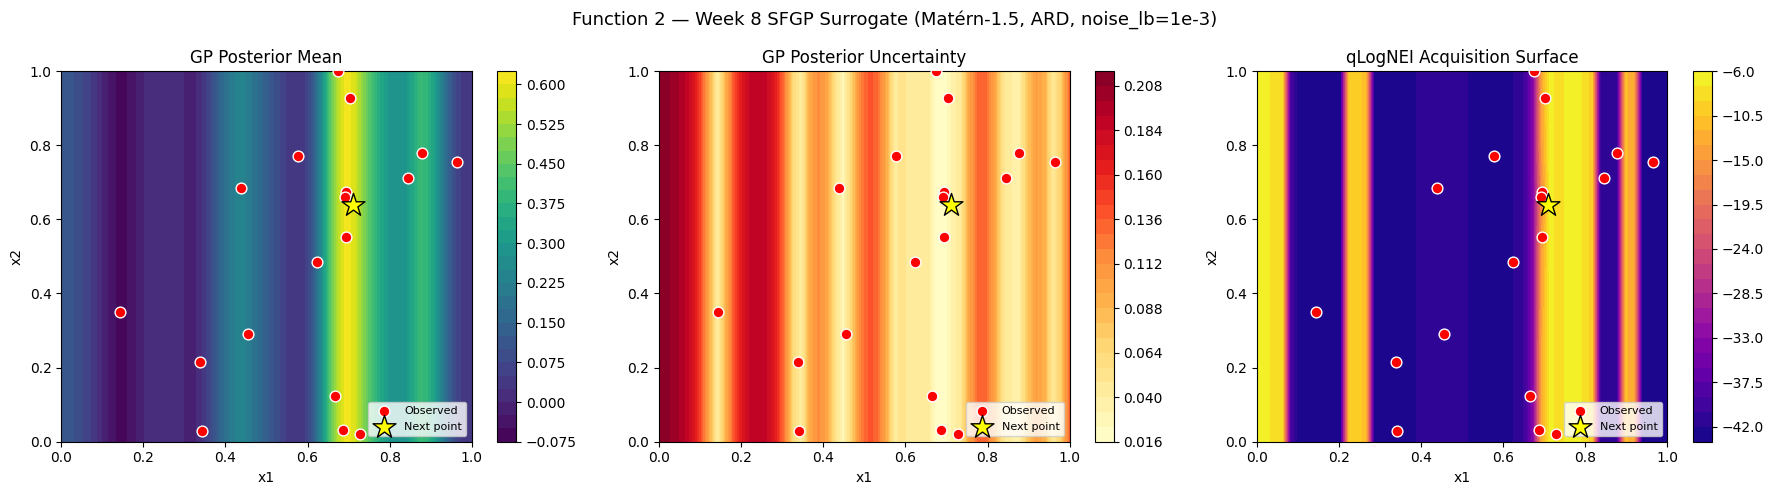

In [6]:
# ── Build 50×50 evaluation grid over [0, 1]² ──────────────────────────────────
n_grid = 50
x1_lin = np.linspace(0, 1, n_grid)
x2_lin = np.linspace(0, 1, n_grid)
X1, X2 = np.meshgrid(x1_lin, x2_lin)
grid_np = np.column_stack([X1.ravel(), X2.ravel()])
grid_t  = torch.tensor(grid_np, dtype=torch.float64)

# ── GP posterior mean and std on grid ─────────────────────────────────────────
model.eval()
with torch.no_grad():
    posterior  = model.posterior(grid_t)
    mean_grid  = posterior.mean.numpy().reshape(n_grid, n_grid)
    std_grid   = posterior.variance.sqrt().numpy().reshape(n_grid, n_grid)

# ── NEI acquisition surface on grid (batched to keep memory manageable) ───────
nei_vals = []
batch_size = 500
nei.eval()
for i in range(0, len(grid_np), batch_size):
    batch = grid_t[i:i + batch_size].unsqueeze(1)   # shape [B, 1, 2]
    with torch.no_grad():
        nei_vals.append(nei(batch).numpy())
nei_grid = np.concatenate(nei_vals).reshape(n_grid, n_grid)

# ── Proposed point clamped to [0, 1] for plotting ─────────────────────────────
x1_plot = max(0.0, min(1.0, x1_next))
x2_plot = max(0.0, min(1.0, x2_next))

# ── Three-panel figure ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel (a): GP Posterior Mean
ax = axes[0]
c = ax.contourf(X1, X2, mean_grid, levels=30, cmap='viridis')
ax.scatter(X_w8[:, 0], X_w8[:, 1], c='red', edgecolors='white', s=60, zorder=5, label='Observed')
ax.scatter(x1_plot, x2_plot, c='yellow', marker='*', s=300, edgecolors='black', zorder=6, label='Next point')
ax.set_xlabel('x1'); ax.set_ylabel('x2')
ax.set_title('GP Posterior Mean')
ax.legend(loc='lower right', fontsize=8)
plt.colorbar(c, ax=ax)

# Panel (b): GP Posterior Uncertainty
ax = axes[1]
c = ax.contourf(X1, X2, std_grid, levels=30, cmap='YlOrRd')
ax.scatter(X_w8[:, 0], X_w8[:, 1], c='red', edgecolors='white', s=60, zorder=5, label='Observed')
ax.scatter(x1_plot, x2_plot, c='yellow', marker='*', s=300, edgecolors='black', zorder=6, label='Next point')
ax.set_xlabel('x1'); ax.set_ylabel('x2')
ax.set_title('GP Posterior Uncertainty')
ax.legend(loc='lower right', fontsize=8)
plt.colorbar(c, ax=ax)

# Panel (c): NEI Acquisition Surface
ax = axes[2]
c = ax.contourf(X1, X2, nei_grid, levels=30, cmap='plasma')
ax.scatter(X_w8[:, 0], X_w8[:, 1], c='red', edgecolors='white', s=60, zorder=5, label='Observed')
ax.scatter(x1_plot, x2_plot, c='yellow', marker='*', s=300, edgecolors='black', zorder=6, label='Next point')
ax.set_xlabel('x1'); ax.set_ylabel('x2')
ax.set_title('qLogNEI Acquisition Surface')
ax.legend(loc='lower right', fontsize=8)
plt.colorbar(c, ax=ax)

plt.suptitle('Function 2 — Week 8 SFGP Surrogate (Matérn-1.5, ARD, noise_lb=1e-3)', fontsize=13)
plt.tight_layout()
plt.show()

### Step 7: Convergence Plot

Running maximum (best observed value) across all 18 observations. Vertical lines separate the initial samples from the weekly submissions.

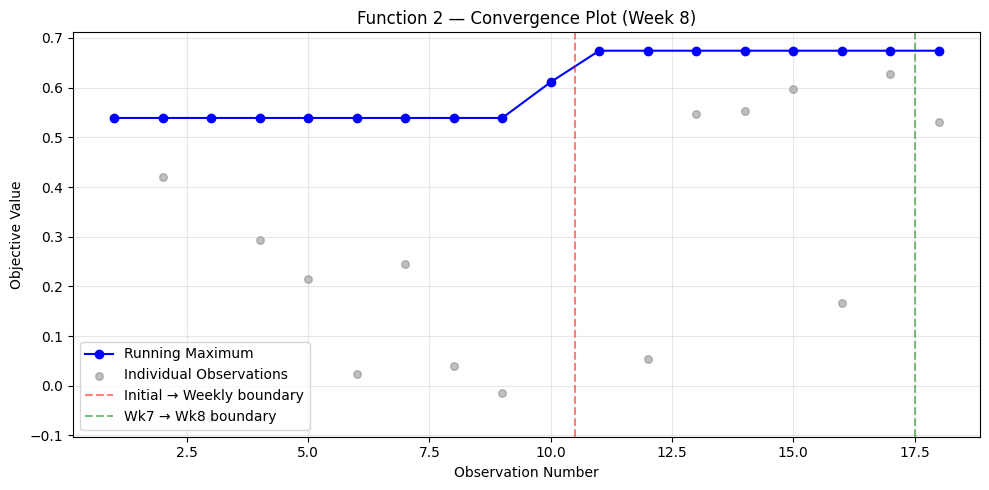

Best observed value: 0.674355
Achieved at observation: 11
Week 8 observation improved best: No — previous best retained


In [7]:
# Running maximum (convergence) over all 18 observations
running_max = np.maximum.accumulate(y_w8)

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(y_w8) + 1), running_max, 'b-o', markersize=6, label='Running Maximum')
plt.scatter(range(1, len(y_w8) + 1), y_w8, c='gray', alpha=0.5, s=30, label='Individual Observations')
plt.axvline(x=10.5, color='red', linestyle='--', alpha=0.5, label='Initial → Weekly boundary')
plt.axvline(x=17.5, color='green', linestyle='--', alpha=0.5, label='Wk7 → Wk8 boundary')
plt.xlabel('Observation Number')
plt.ylabel('Objective Value')
plt.title('Function 2 — Convergence Plot (Week 8)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Best observed value: {y_w8.max():.6f}")
print(f"Achieved at observation: {y_w8.argmax() + 1}")
improved = y_w8[-1] > np.max(y_w8[:-1])
print(f"Week 8 observation improved best: {'Yes ✓' if improved else 'No — previous best retained'}")

### Step 8: Format Submission Query

Format the proposed next sample point as `x1-x2` with 6 decimal places, clamped to `[0.0, 0.999999]`.

In [8]:
# Clamp proposed point to valid submission bounds [0.0, 0.999999]
x1_sub = max(0.0, min(0.999999, x1_next))
x2_sub = max(0.0, min(0.999999, x2_next))

# Verify no duplicate with existing observations
observed_queries = [f"{X_w8[i,0]:.6f}-{X_w8[i,1]:.6f}" for i in range(len(X_w8))]
proposed_query = f"{x1_sub:.6f}-{x2_sub:.6f}"
is_duplicate = proposed_query in observed_queries

print("=" * 60)
print("WEEK 8 SUBMISSION QUERY FOR FUNCTION 2")
print("=" * 60)
print(f"Surrogate:   SFGP (Matérn-1.5, ARD=True, noise_lb={NOISE_LB})")
print(f"Acquisition: qLogNoisyExpectedImprovement (qLogNEI)")
print(f"Lengthscales: x1={lengthscales[0]:.4f}, x2={lengthscales[1]:.4f}")
print(f"Noise level:  {noise:.6f}")
print(f"Best observed y: {y_w8.max():.6f}")
print(f"Proposed next:   [{x1_sub:.6f}, {x2_sub:.6f}]")
print(f"Duplicate check: {'⚠ DUPLICATE — resample needed' if is_duplicate else 'OK — unique point'}")
print(f"\n>>> SUBMISSION: {proposed_query}")
print("=" * 60)

WEEK 8 SUBMISSION QUERY FOR FUNCTION 2
Surrogate:   SFGP (Matérn-1.5, ARD=True, noise_lb=0.001)
Acquisition: qLogNoisyExpectedImprovement (qLogNEI)
Lengthscales: x1=0.0906, x2=4997.9988
Noise level:  0.020237
Best observed y: 0.674355
Proposed next:   [0.709948, 0.637656]
Duplicate check: OK — unique point

>>> SUBMISSION: 0.709948-0.637656
